In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets,layers,losses,Model
from random import randint

from tensorflow.python.keras.saving.saved_model.save_impl import input_layer

In [2]:
(x_train,y_train),(x_test,y_test)=(
    tf.keras.datasets.mnist.load_data())

In [3]:
#############################################################################
#Designing encoder
input_layer = layers.Input(shape = x_train.shape[1:])#if we print xtrain shape we get tuple (60000,28,28)
flattened = layers.Flatten()(input_layer)# this will get input as #784 neurons
hidden = layers.Dense(100,activation = 'relu')(flattened)
latent = layers.Dense(20,activation = 'relu')(hidden)
encoder = Model(inputs = input_layer,
                outputs = latent,
                name = 'encoder'
                )
encoder.summary()


Model: "encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 100)               78500     
                                                                 
 dense_1 (Dense)             (None, 20)                2020      
                                                                 
Total params: 80520 (314.53 KB)
Trainable params: 80520 (314.53 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [4]:
############################################################
#Designing Decoder
input_layer_decoder = layers.Input(shape = encoder.output.shape[1:])#iss mein jae ga 20
upsampled = layers.Dense(100,activation = 'relu')(input_layer_decoder)
upsampled2 = layers.Dense(784,activation = 'relu')(upsampled)
constructed = layers.Reshape(x_train.shape[1:])(upsampled2)
decoder = Model(inputs = input_layer_decoder,
                outputs = constructed,
                name = 'decoder'
                )
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 20)]              0         
                                                                 
 dense_2 (Dense)             (None, 100)               2100      
                                                                 
 dense_3 (Dense)             (None, 784)               79184     
                                                                 
 reshape (Reshape)           (None, 28, 28)            0         
                                                                 
Total params: 81284 (317.52 KB)
Trainable params: 81284 (317.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
##################################################################
#Designing Autoencoder
autoencoder = Model(inputs = encoder.input,
                    outputs = decoder(encoder.output))
autoencoder.summary()
autoencoder.compile(optimizer = 'adam',
                    loss = losses.MeanSquaredError(),
                    metrics = ['accuracy']
                    )
summary = autoencoder.fit(x_train,x_train,epochs = 5,batch_size=32,validation_data=(x_test,x_test))

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 100)               78500     
                                                                 
 dense_1 (Dense)             (None, 20)                2020      
                                                                 
 decoder (Functional)        (None, 28, 28)            81284     
                                                                 
Total params: 161804 (632.05 KB)
Trainable params: 161804 (632.05 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

Epoch 1/5


1875/187

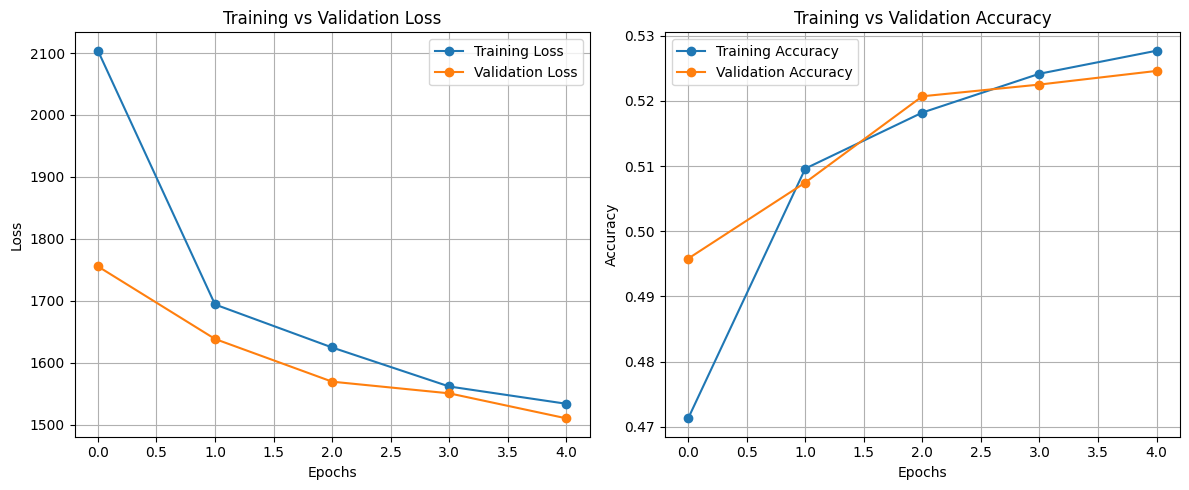

In [6]:
# you have to plot accuracy and loss of training and testing
plt.figure(figsize=(12,5))
# Plot Loss
plt.subplot(1,2,1)
plt.plot(summary.history['loss'], label='Training Loss', marker='o')
plt.plot(summary.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(summary.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(summary.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

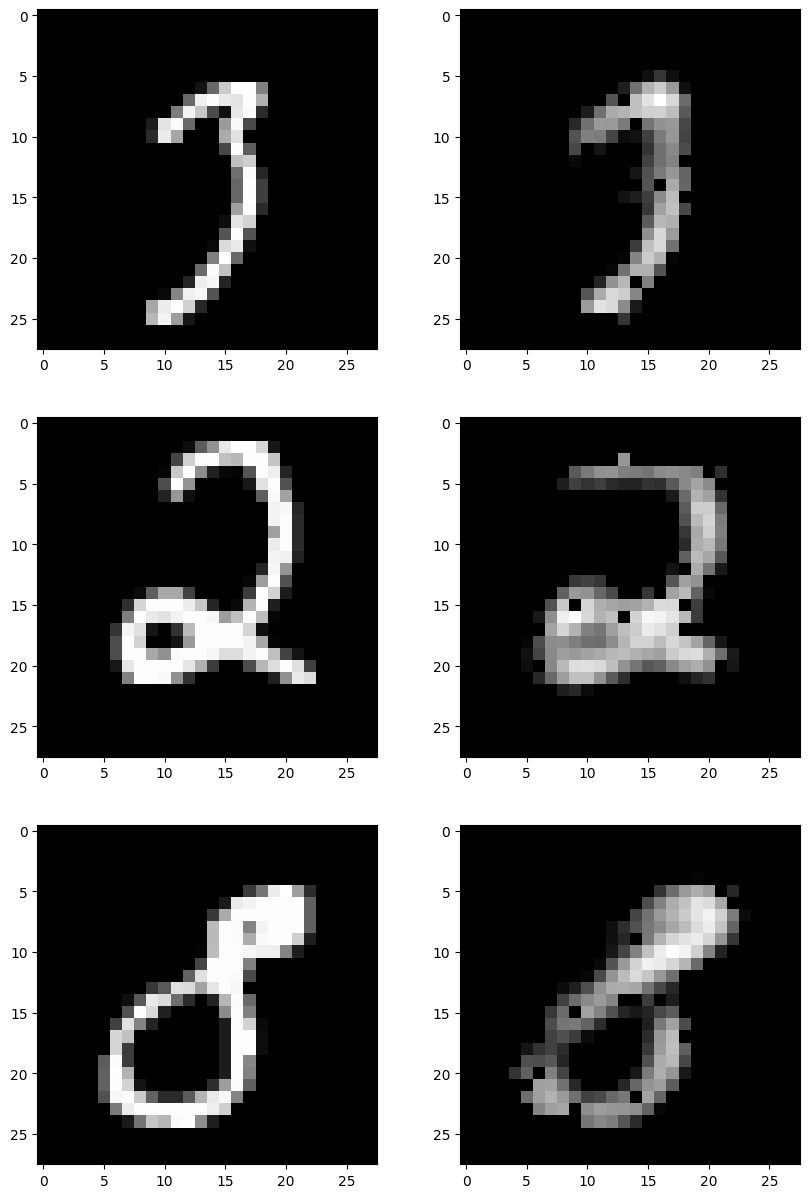

In [ ]:
###################################################################################
fig,axs = plt.subplots(3,2,figsize = (10,15))
for i in range(3):
    sample = x_train[randint(0,x_train.shape[0])] # 0 TO 60000
    axs[i][0].imshow(sample,cmap='gray')
    axs[i][1].imshow(autoencoder(np.expand_dims(sample,0))[0],cmap = 'gray')#(1,28,28)
plt.show()
#apply autoencoder on your own dataset on only one category apply 110 resolution